In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1)

Разрешение изображения:  (256, 256)


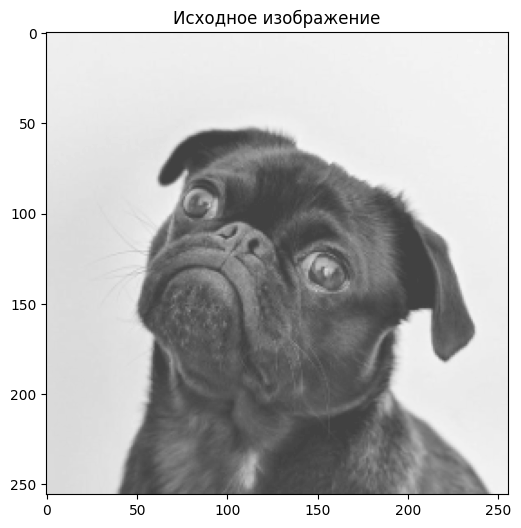

In [2]:
pic = plt.imread("dog.png")

if len(pic.shape) == 3:
    pic = np.mean(pic, axis=2)

if pic.dtype != np.uint8:
    pic = (pic * 255).astype(np.uint8)

plt.figure(figsize=(12,6))
print("Разрешение изображения: ", pic.shape)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное изображение")
plt.show()

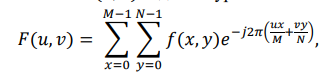

In [3]:
def FFT_2d(pic):
    fft_rows = np.fft.fft(pic, axis=0)
    
    fft_2d = np.fft.fft(fft_rows, axis=1)
    return fft_2d


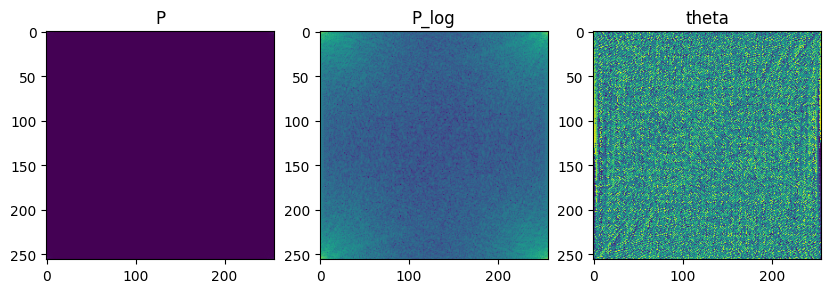

In [5]:
fft = FFT_2d(pic)

P = np.abs(fft)  
theta = np.angle(fft)  
   
P_log = np.log(1 + P)

plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(P)
plt.title("P")


plt.subplot(1,3,2)
plt.imshow(P_log)
plt.title("P_log")

plt.subplot(1,3,3)
plt.imshow(theta)
plt.title("theta")
plt.show()

### 2) 

In [6]:
def IFFT_1d(fft_2d, x,y):
    tmp = 0
    for u in range(fft_2d.shape[0]):
        for v in range(fft_2d.shape[1]):
            tmp+= fft_2d[u][v] * np.exp(1j * 2 * np.pi *(u*x/fft_2d.shape[0] + y*v/fft_2d.shape[1]))

    return tmp
            

def IFFT_2d_old(fft_2d):
    new_pic = np.zeros((fft_2d.shape[0],fft_2d.shape[1]))

    for x in range(fft_2d.shape[0]):
        for y in range(fft_2d.shape[1]):
            new_pic[x][y] = 1/(fft_2d.shape[0] * fft_2d.shape[1]) * IFFT_1d(fft_2d, x,y)

    return new_pic

In [7]:
def IFFT_2d(fft_2d):
    
    M, N = fft_2d.shape
    result = np.zeros((M, N), dtype=complex)
    u = np.arange(M).reshape(M, 1)
    v = np.arange(N).reshape(1, N)
            

    for x in range(M):
        for y in range(N):
            
            exponent = 1j * 2 * np.pi * (u * x / M + v * y / N)
            result[x, y] = np.sum(fft_2d * np.exp(exponent))
    
    return result / (M * N)

In [8]:
PIC = IFFT_2d(fft)

In [9]:
PIC

array([[238.-1.77635684e-15j, 238.-1.24344979e-14j, 238.+7.10542736e-15j,
        ..., 244.-7.90478794e-14j, 244.-1.22124533e-13j,
        244.-1.24344979e-13j],
       [239.-8.88178420e-15j, 239.-2.48689958e-14j, 239.+3.55271368e-14j,
        ..., 244.-7.58060281e-13j, 244.-7.37188088e-14j,
        243.-1.39444012e-13j],
       [239.-7.10542736e-15j, 239.-1.42108547e-14j, 239.+5.32907052e-15j,
        ..., 244.-1.96109795e-12j, 244.-3.75299791e-12j,
        243.-2.77999845e-13j],
       ...,
       [219.+9.76996262e-14j, 218.+1.88649096e-12j, 218.-1.89892546e-12j,
        ..., 242.-5.71453995e-12j, 241.-4.68247663e-12j,
        241.-1.36823886e-12j],
       [219.+1.47437618e-13j, 218.+5.20472554e-13j, 218.+3.44613227e-13j,
        ..., 242.-5.36504174e-12j, 241.-7.81996690e-12j,
        241.-3.71080944e-12j],
       [219.+2.00728323e-13j, 218.+2.09965378e-12j, 218.+3.06776826e-12j,
        ..., 242.-5.49782442e-12j, 241.-6.36068975e-12j,
        242.-5.75939296e-12j]])

In [10]:
res = PIC.astype(np.uint8)
error_map = pic - res

C:\Users\vlade\AppData\Local\Temp\ipykernel_12280\3629734069.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  res = PIC.astype(np.uint8)


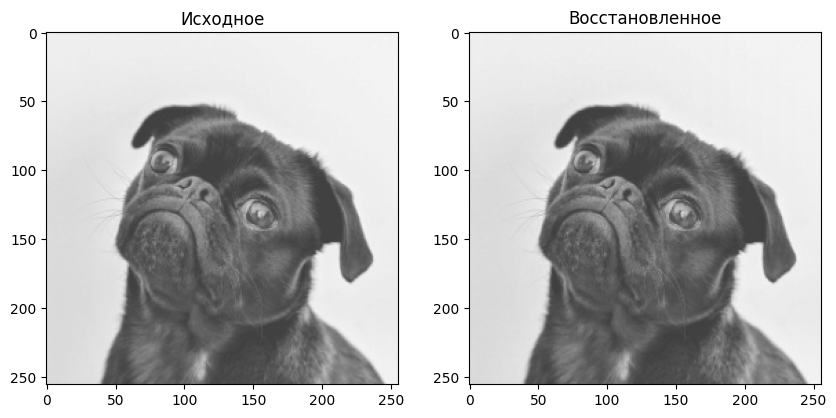

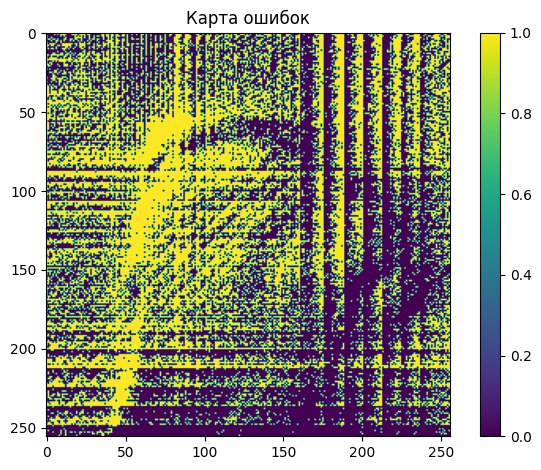

In [16]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(res, cmap='gray',vmin=0,vmax=255)
plt.title("Восстановленное")
plt.show()


plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

### 3)

#### a)

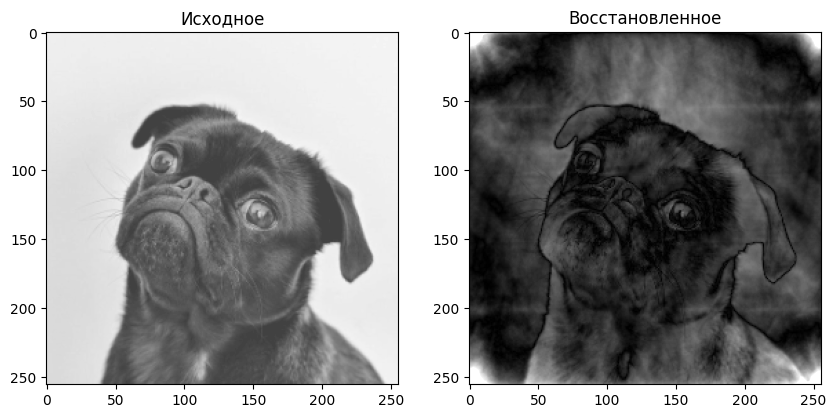

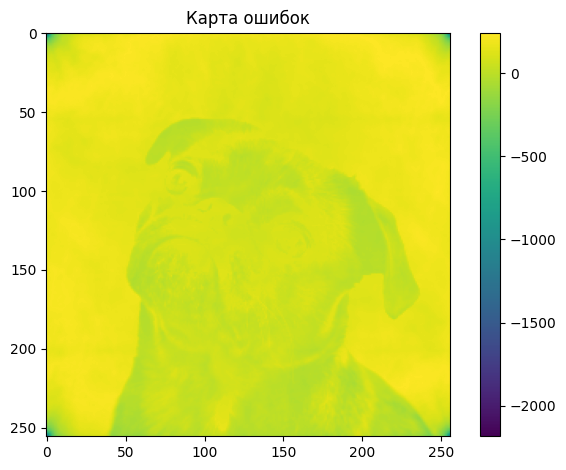

In [36]:
def simple_zero_phase_demo(pic):
    fft_spectrum = np.fft.fft2(pic)
    
    amplitudes = np.abs(fft_spectrum)
    fft_zero_phase = amplitudes  
    
    restored = np.real(np.fft.ifft2(fft_zero_phase))

    return np.abs(pic - restored)

n_pic = simple_zero_phase_demo(pic)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(n_pic, cmap='gray',vmin=0,vmax=255)
plt.title("Восстановленное")
plt.show()

error_map = pic - n_pic
plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

#### b)

In [42]:
def amplitude_one(pic):
    fft_spectrum = np.fft.fft2(pic)
    apl = np.abs(fft_spectrum)
    phs = np.angle(fft_spectrum)

    apl_1 = apl.copy()
    apl_1[:,:] = 1
    new_fft = np.real(apl_1).astype(complex) + 1j*phs.astype(complex)

    new_pic = np.fft.ifft2(new_fft)


    return np.real(new_pic)

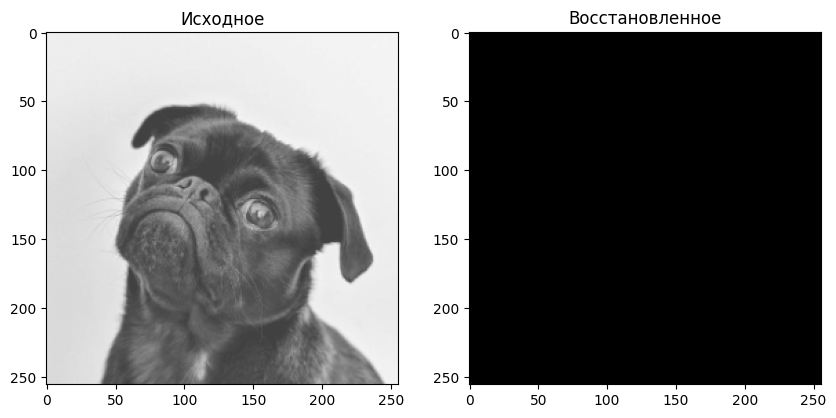

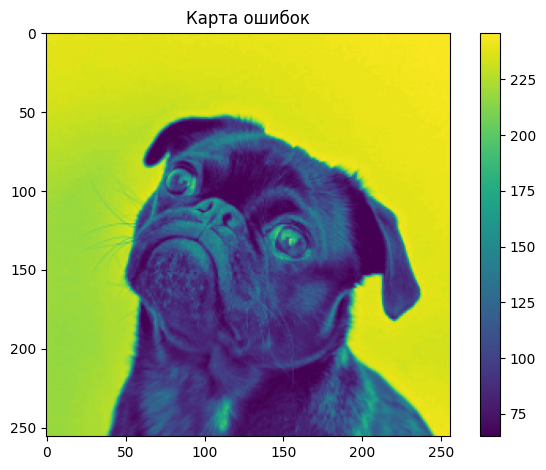

In [43]:
one_pic = amplitude_one(pic)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(one_pic, cmap='gray',vmin=0,vmax=255)
plt.title("Восстановленное")
plt.show()

error_map = pic - one_pic
plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

### 4)

#### a)

In [ ]:
n0 = 6
K1 = 3*n0